In [73]:
!pip install prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
!pip install openpyxl


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
df = pd.read_excel('cleaned_superstore_dataset.xlsx')
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,order_weekday,shipping_time_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Tuesday,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Tuesday,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Sunday,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Sunday,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Sunday,7


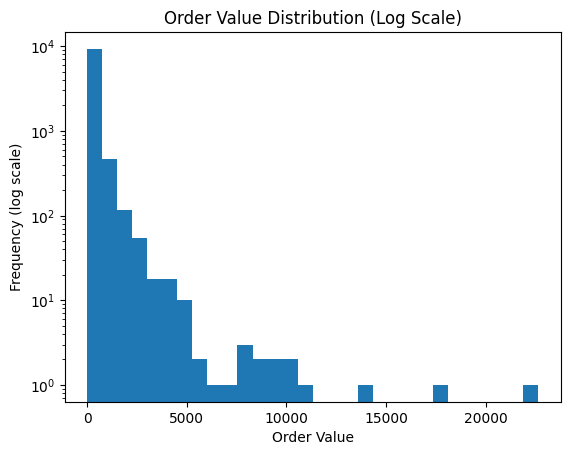

In [76]:
plt.figure()
plt.hist(df['sales'], bins=30)
plt.yscale('log')   
plt.title("Order Value Distribution (Log Scale)")
plt.xlabel("Order Value")
plt.ylabel("Frequency (log scale)")
plt.show()

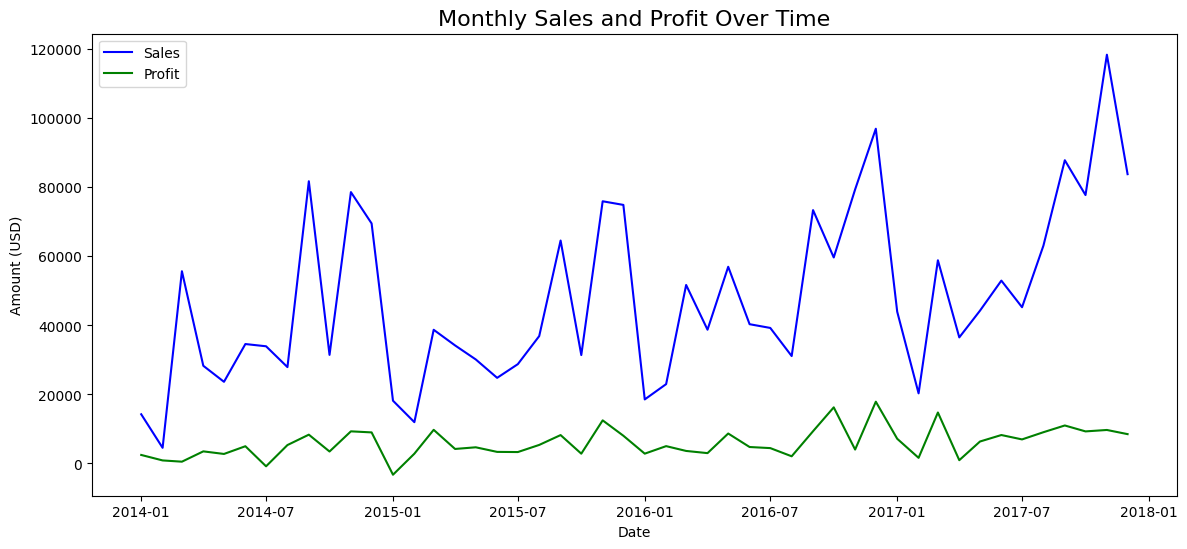

In [77]:
monthly_analysis = df.set_index('order_date')[['sales', 'profit']].resample('MS').sum()
plt.figure(figsize=(14, 6))
plt.plot(monthly_analysis.index, monthly_analysis['sales'], label='Sales', color='blue')
plt.plot(monthly_analysis.index, monthly_analysis['profit'], label='Profit', color='green')
plt.title('Monthly Sales and Profit Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Amount (USD)')
plt.legend()
plt.show()

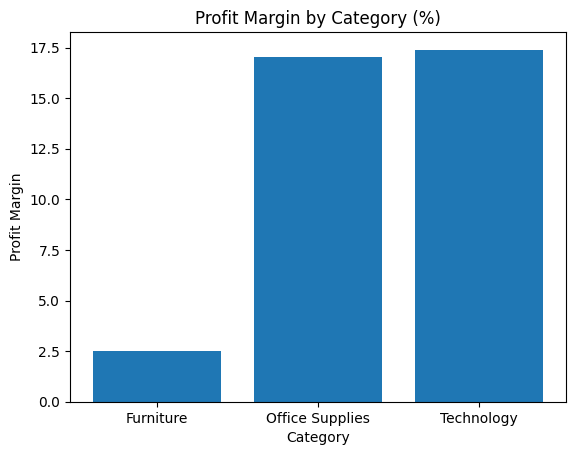

In [78]:
category = df.groupby('category').agg({
    'sales': 'sum',
    'profit': 'sum'
}).reset_index()
category['profit_margin'] = (category['profit'] / category['sales']) * 100
plt.figure()
plt.bar(category['category'], category['profit_margin'])
plt.title("Profit Margin by Category (%)")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.show()

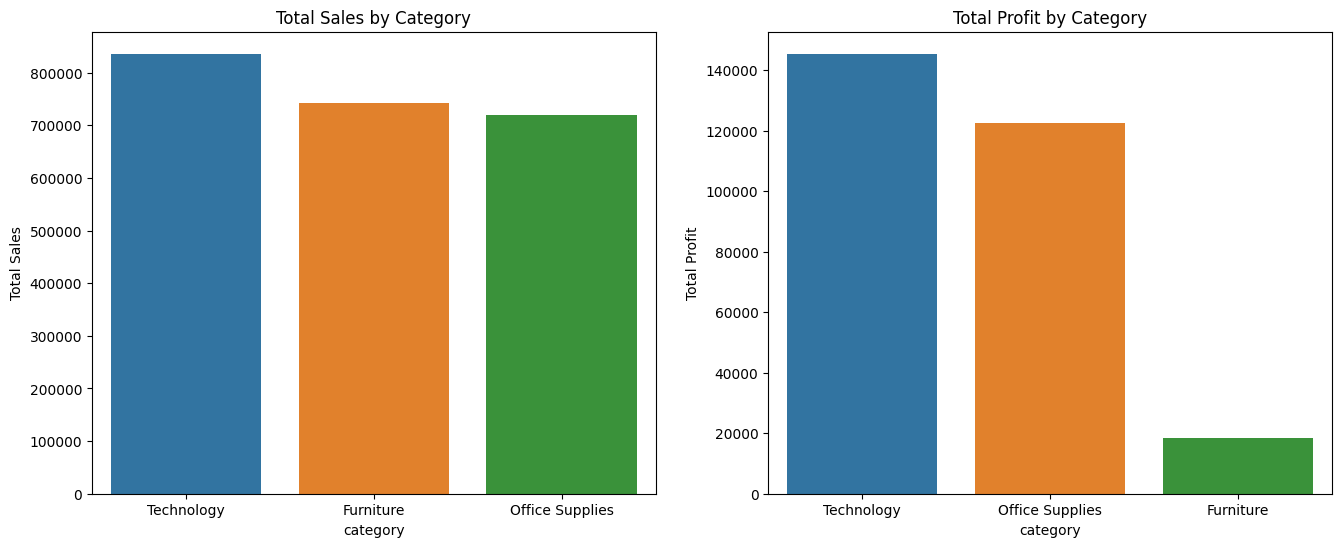

In [79]:
category_profit = df.groupby('category')['profit'].sum().reset_index().sort_values(by='profit', ascending=False)
category_sales = df.groupby('category')['sales'].sum().reset_index().sort_values(by='sales', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=category_sales, x='category', y='sales', hue='category', legend=False, ax=axes[0])
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Total Sales')
sns.barplot(data=category_profit, x='category', y='profit', hue='category', legend=False, ax=axes[1])
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Total Profit')
plt.show()

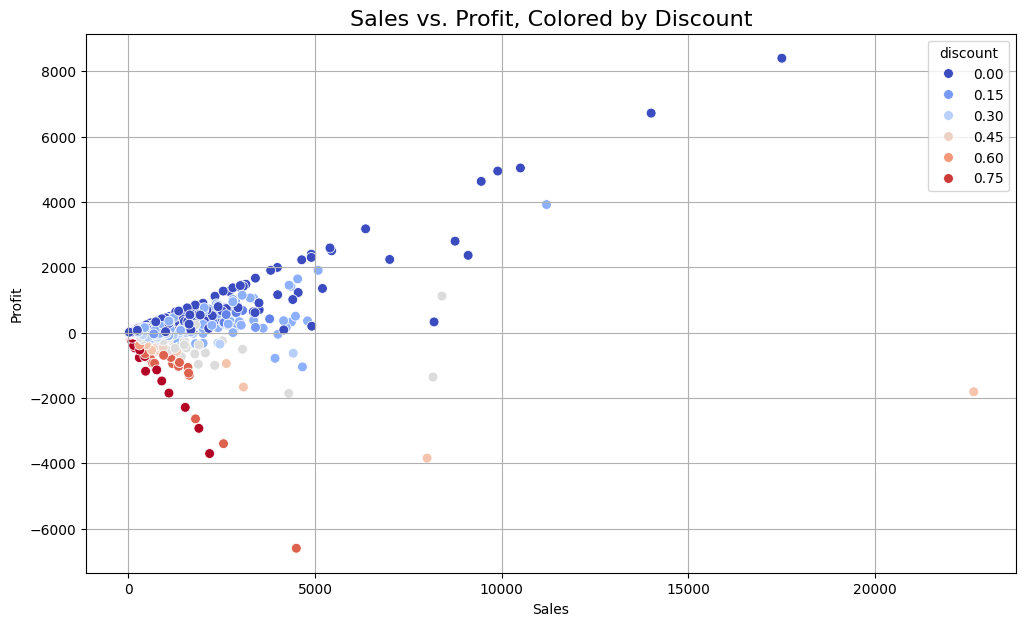

In [80]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='sales', y='profit', hue='discount', palette='coolwarm', s=50)
plt.title('Sales vs. Profit, Colored by Discount', fontsize=16)
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid()
plt.show()

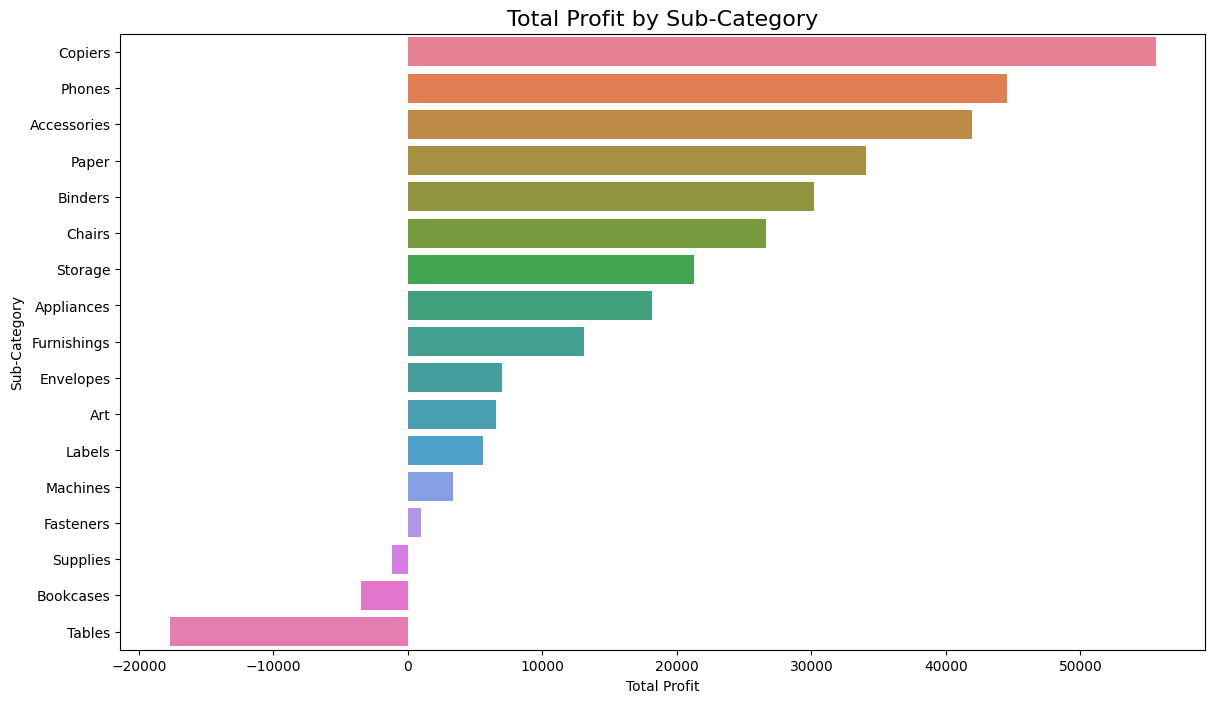

In [81]:
subcategory_profit = df.groupby('sub_category')['profit'].sum().reset_index().sort_values(by='profit', ascending=False)
plt.figure(figsize=(14, 8))
sns.barplot(data=subcategory_profit, y='sub_category', x='profit', hue='sub_category', legend=False)
plt.title('Total Profit by Sub-Category', fontsize=16)
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.show()

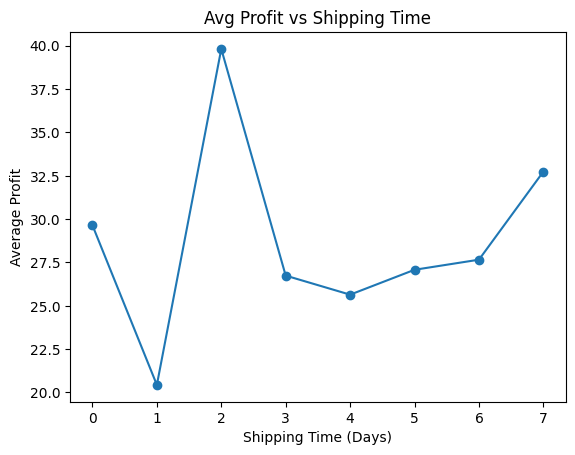

In [82]:
shipping_analysis = df.groupby('shipping_time_days').agg({
    'profit': 'mean'
}).reset_index()
plt.figure()
plt.plot(shipping_analysis['shipping_time_days'],
         shipping_analysis['profit'],
         marker='o')
plt.title("Avg Profit vs Shipping Time")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Average Profit")
plt.show()

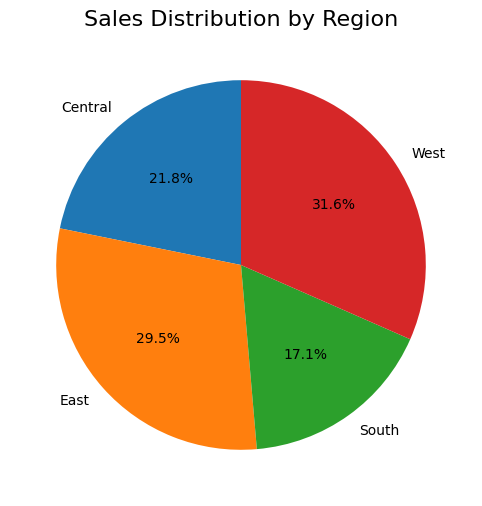

In [83]:
region_sales = df.groupby('region')['sales'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.pie(region_sales['sales'], labels=region_sales['region'], autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Region', fontsize=16)
plt.ylabel('')
plt.show()

In [84]:
du= pd.read_csv('segmented_customers.csv')

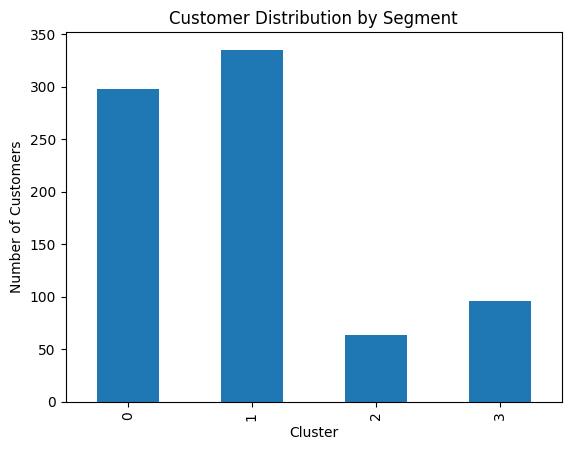

In [85]:
segment_counts = du['cluster'].value_counts().sort_index()
plt.figure()
segment_counts.plot(kind='bar')
plt.title("Customer Distribution by Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

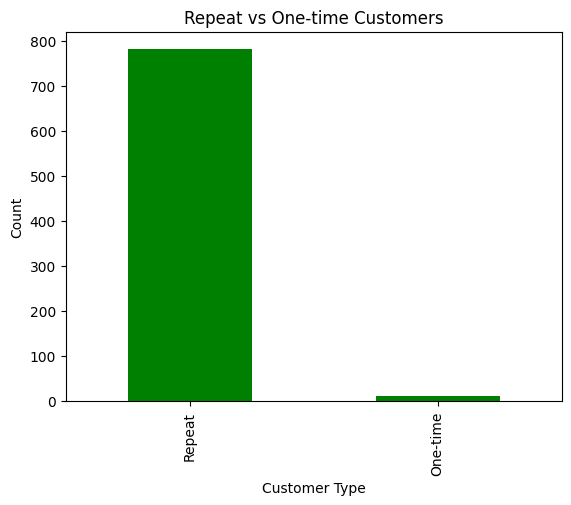

In [86]:
customer_orders = df.groupby('customer_id')['order_id'].nunique()
customer_type = customer_orders.apply(lambda x: 'One-time' if x == 1 else 'Repeat')
counts = customer_type.value_counts()
plt.figure()
counts.plot(kind='bar',color='green')
plt.title("Repeat vs One-time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

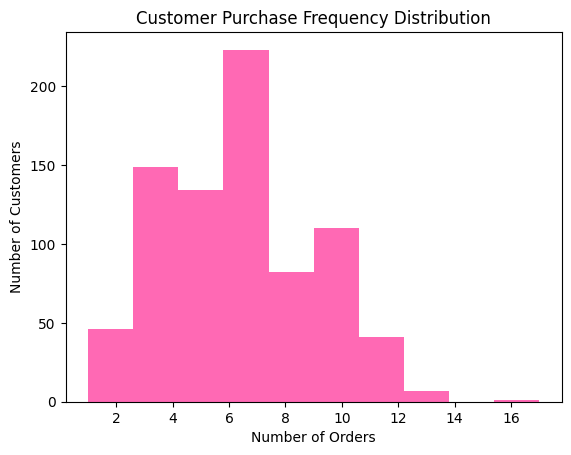

In [87]:
customer_freq = df.groupby('customer_id')['order_id'].nunique()
plt.figure()
plt.hist(customer_freq,color='hotpink')
plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

In [88]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password="navi@2006",   
    host="localhost",
    port=5432,
    database="store_database"  
)
engine = create_engine(url)
print("Engine created successfully")

Engine created successfully


In [89]:
query_rfm = """
WITH rfm_data AS (
    SELECT
        customer_id,
        customer_name,
        CURRENT_DATE - MAX(order_date) AS recency,
        COUNT(DISTINCT order_id) AS frequency,
        SUM(sales) AS monetary
    FROM dt
    GROUP BY customer_id, customer_name
)
SELECT * FROM rfm_data;
"""

In [90]:
rfm_df = pd.read_sql(query_rfm, engine)
display(rfm_df.head())

,customer_id,customer_name,recency,frequency,monetary
0,AA-10315,Alex Avila,3273 days,5,5563.560
1,AA-10375,Allen Armold,3108 days,9,1056.390
2,AA-10480,Andrew Allen,3348 days,4,1790.512
3,AA-10645,Anna Andreadi,3144 days,6,5086.935
4,AB-10015,Aaron Bergman,3504 days,3,886.156


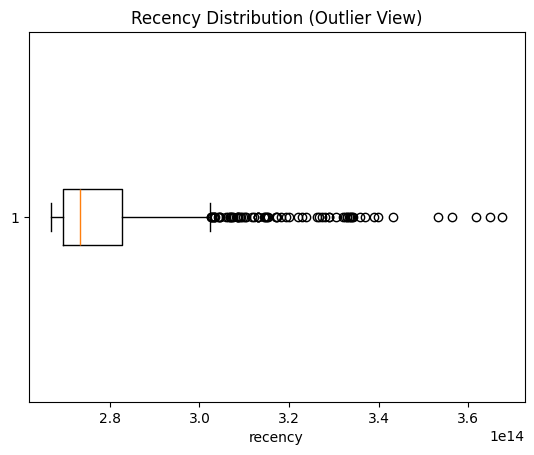

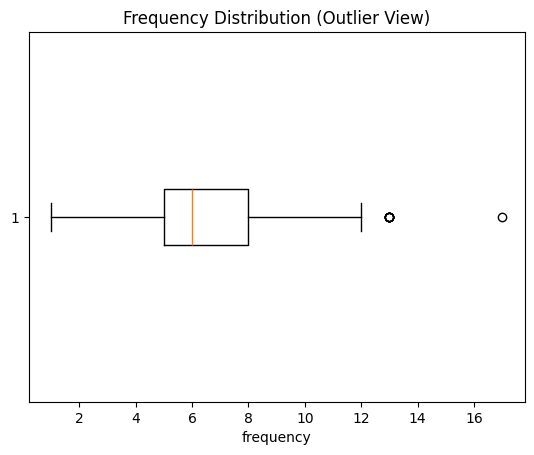

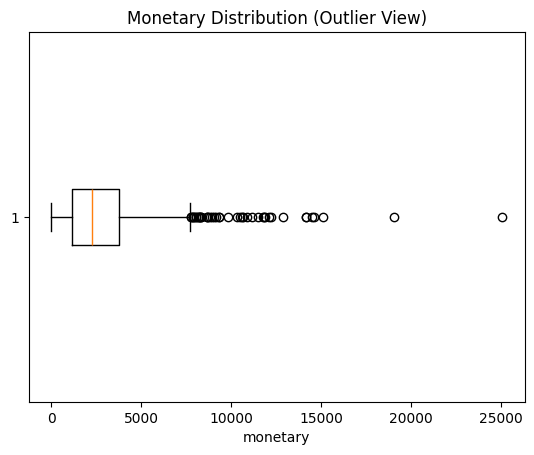

In [91]:
for col in ['recency', 'frequency', 'monetary']:
    plt.figure()
    plt.boxplot(rfm_df[col], vert=False)
    plt.title(f'{col.capitalize()} Distribution (Outlier View)')
    plt.xlabel(col)
    plt.show()

In [92]:
if str(rfm_df['recency'].dtype).startswith('timedelta'):
    rfm_df['recency'] = rfm_df['recency'].dt.days
rfm_df['avg_order_value'] = rfm_df['monetary'] / rfm_df['frequency']
rfm_df['value_density'] = rfm_df['monetary'] / (rfm_df['recency'] + 1)

In [93]:
rfm_features = rfm_df[['recency', 'frequency', 'monetary']]

In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
print("Scaling done.")

Scaling done.


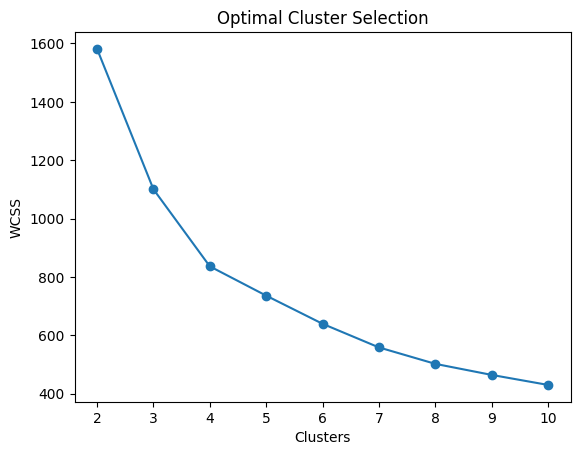

In [95]:
from sklearn.cluster import KMeans
wcss = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    wcss.append(model.inertia_)
plt.figure()
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Optimal Cluster Selection")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [96]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
rfm_df['cluster'] = kmeans.fit_predict(rfm_scaled)
print("Clustering complete.")

Clustering complete.


,recency,frequency,monetary
cluster,,,
0,3160.741611,8.516779,3322.222985
1,3189.197015,4.731343,1669.688290
2,3211.718750,8.296875,9479.545687
3,3647.489583,3.697917,1470.228226


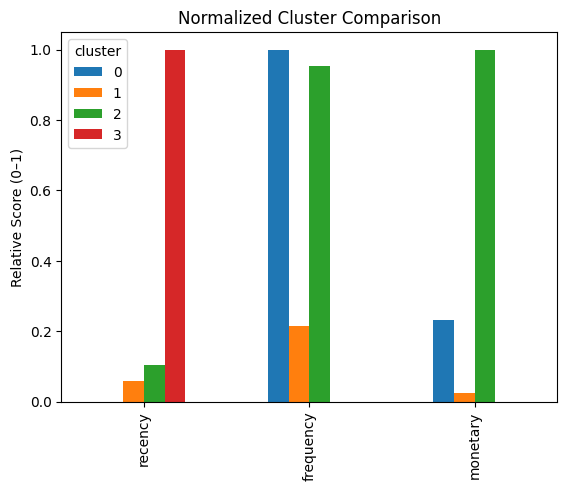

In [97]:
cluster_analysis = rfm_df.groupby('cluster')[['recency', 'frequency', 'monetary']].mean()
display(cluster_analysis)
normalized = (cluster_analysis - cluster_analysis.min()) / (cluster_analysis.max() - cluster_analysis.min())
normalized.T.plot(kind='bar')
plt.title("Normalized Cluster Comparison")
plt.ylabel("Relative Score (0–1)")
plt.show()

In [98]:
rfm_df.to_csv('segmented_customers.csv', index=False)
print("Segmented data saved.")

Segmented data saved.


In [99]:
sales_monthly = df.set_index('order_date')['sales'].resample('MS').sum().reset_index()
sales_monthly.columns = ['ds', 'y']

display(sales_monthly.head())

,ds,y
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


In [100]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.9
)
model.fit(sales_monthly)
print("Model trained.")

18:59:40 - cmdstanpy - INFO - Chain [1] start processing
18:59:41 - cmdstanpy - INFO - Chain [1] done processing


Model trained.


In [101]:
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)
print("Forecast generated.")

Forecast generated.


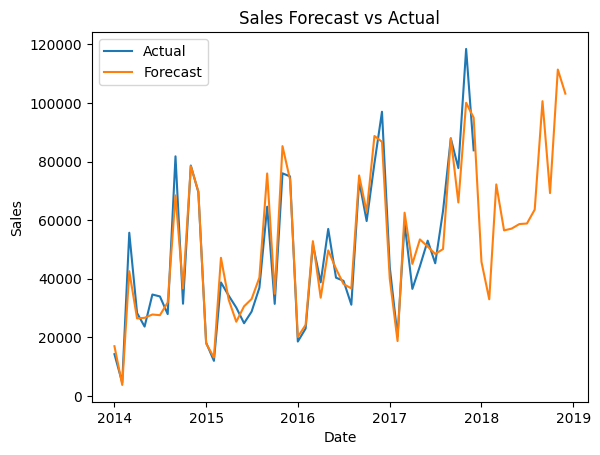

In [102]:
plt.figure()
plt.plot(sales_monthly['ds'], sales_monthly['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.title("Sales Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [103]:
df['is_profitable'] = (df['profit'] > 0).astype(int)

In [104]:
df['discount_effect'] = df['discount'] * df['sales']
numerical_features = ['sales', 'quantity', 'discount']
categorical_features = ['ship_mode', 'segment', 'region', 'category']
X = pd.get_dummies(df[numerical_features + categorical_features], drop_first=True)
y = df['is_profitable']

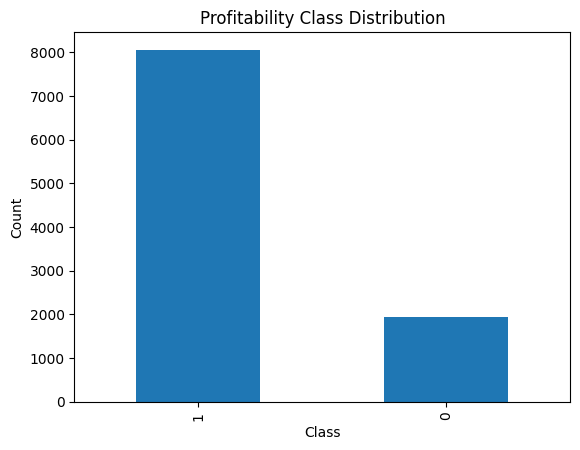

In [105]:
counts = y.value_counts()
plt.figure()
counts.plot(kind='bar')
plt.title("Profitability Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [106]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

              precision    recall  f1-score   support

           0       0.99      0.70      0.82       387
           1       0.93      1.00      0.96      1612

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.89      1999
weighted avg       0.94      0.94      0.94      1999



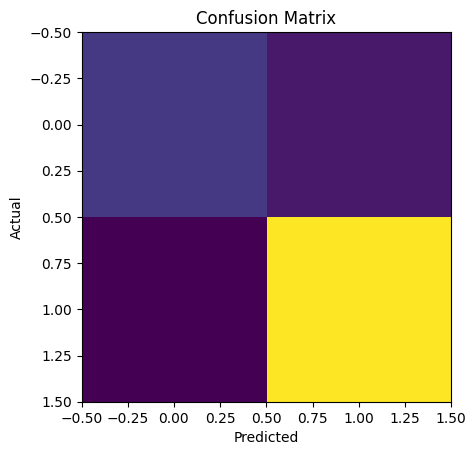

In [108]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [109]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)
display(importances.head(10))

,feature,importance
2,discount,0.852013
0,sales,0.061322
11,category_Office Supplies,0.020929
10,region_West,0.019536
12,category_Technology,0.016679
1,quantity,0.012770
8,region_East,0.004769
9,region_South,0.003599
6,segment_Corporate,0.002113
7,segment_Home Office,0.002073


In [111]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 94.00%


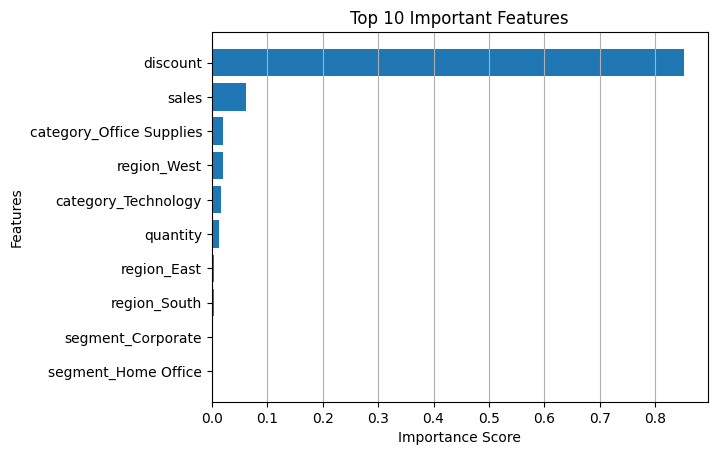

In [112]:
top_features = importances.head(10)
plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # highest at top
plt.grid(axis='x')
plt.show()